# Pizza Place Sales Analysis

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
# Load datasets
orders = pd.read_csv("orders.csv")

order_details = pd.read_csv("order_details.csv")

pizzas = pd.read_csv("pizzas.csv")

pizza_types = pd.read_csv("pizza_types.csv", encoding="latin1")

In [60]:
df = order_details.merge(pizzas, on="pizza_id")
df = df.merge(pizza_types, on="pizza_type_id")
df = df.merge(orders, on="order_id")

## Question 1: What is the Total Revenue?

In [61]:
df["revenue"] = df["quantity"] * df["price"]

total_revenue = df["revenue"].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 817860.0499999999


### Insight

The total revenue represents the overall financial performance of the pizza business during the one-year period. A high total revenue indicates strong customer demand and effective sales performance. This metric helps the business evaluate its profitability and overall success. It can also serve as a benchmark for future performance comparison and business growth evaluation.

## Question 2: What is the Total Quantity Sold?

In [62]:
total_quantity = df["quantity"].sum()

print("Total Quantity Sold:", total_quantity)

Total Quantity Sold: 49574


### Insight

The total quantity sold reflects the volume of pizzas purchased by customers over the year. This shows the level of customer demand and consumption.

## Question 3: What is the Total Number of Orders?

In [63]:
total_orders = df["order_id"].nunique()

print("Total Orders:", total_orders)

Total Orders: 21350


### Insight

This represents the total number of customer orders placed.

## Question 4: How Many Pizza Types are Sold?

In [64]:
pizza_types_count = df["pizza_type_id"].nunique()

print("Number of Pizza Types:", pizza_types_count)

Number of Pizza Types: 32


### Insight

This shows the number of different pizza types available.

## Question 5: What is the Average Price of Pizza?

In [65]:
average_price = df["price"].mean()

print("Average Price:", average_price)

Average Price: 16.494132044426163


### Insight

This represents the average cost of a pizza.

## Question 6: What are the Peak Sales Hours?

In [66]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["time"] = pd.to_datetime(df["time"], format="%H:%M:%S", errors="coerce")

In [67]:
df["revenue"] = df["quantity"] * df["price"]

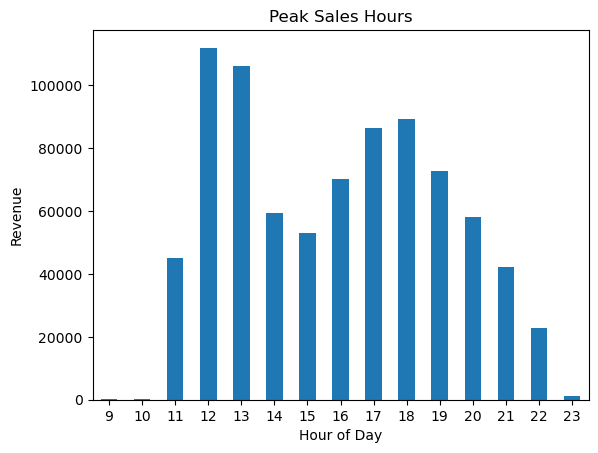

hour
9         83.00
10       303.65
11     44935.80
12    111877.90
13    106065.70
14     59201.40
15     52992.30
16     70055.40
17     86237.45
18     89296.85
19     72628.90
20     58215.40
21     42029.80
22     22815.15
23      1121.35
Name: revenue, dtype: float64

In [68]:
df["hour"] = df["time"].dt.hour

hourly_sales = df.groupby("hour")["revenue"].sum().sort_index()

ax = hourly_sales.plot(kind="bar")
plt.title("Peak Sales Hours")
plt.xlabel("Hour of Day")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.show()

hourly_sales

### Insight

This indicates that customers prefer ordering pizza during lunch and dinner hours.

## Question 7: Find the total sales made on each day of the week. Which day of the week is when sales are made the most?

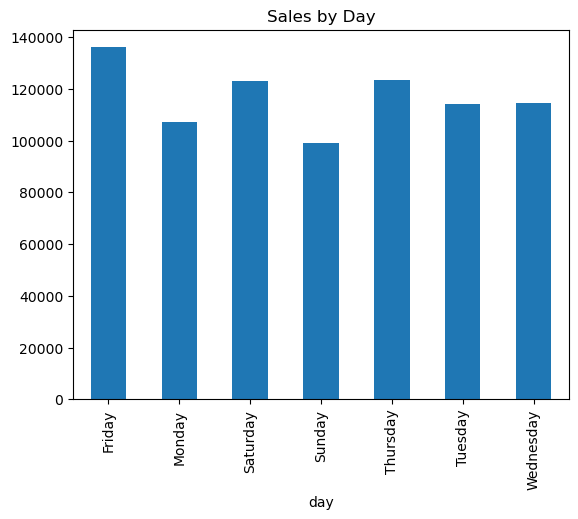

In [69]:
df["date"] = pd.to_datetime(df["date"])

df["day"] = df["date"].dt.day_name()

sales_by_day = df.groupby("day")["revenue"].sum()

sales_by_day.plot(kind="bar")

plt.title("Sales by Day")

plt.show()

### Insight

This helps identify the busiest day of the week.

## Question 8: What are the Top 5 Best Selling Pizzas?

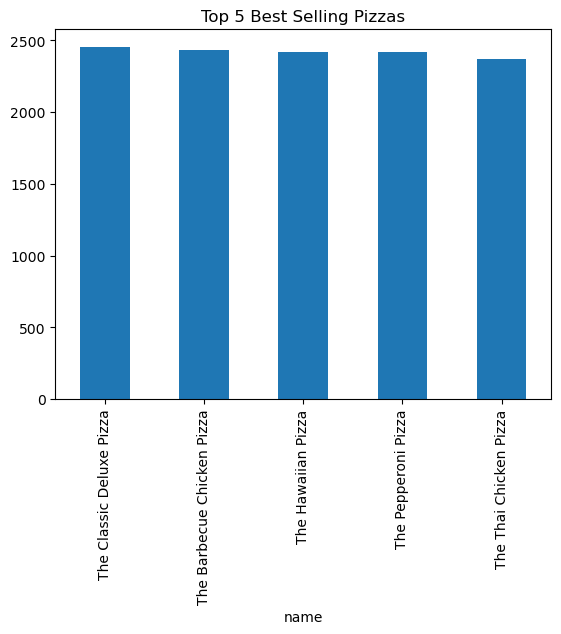

name
The Classic Deluxe Pizza      2453
The Barbecue Chicken Pizza    2432
The Hawaiian Pizza            2422
The Pepperoni Pizza           2418
The Thai Chicken Pizza        2371
Name: quantity, dtype: int64

In [70]:
top5 = df.groupby("name")["quantity"].sum().sort_values(ascending=False).head(5)

top5.plot(kind="bar")

plt.title("Top 5 Best Selling Pizzas")

plt.show()

top5

### Insight

These pizzas are the most popular and generate the most demand.

## Question 9: Find the sales made in each month. Any trend noticeable?

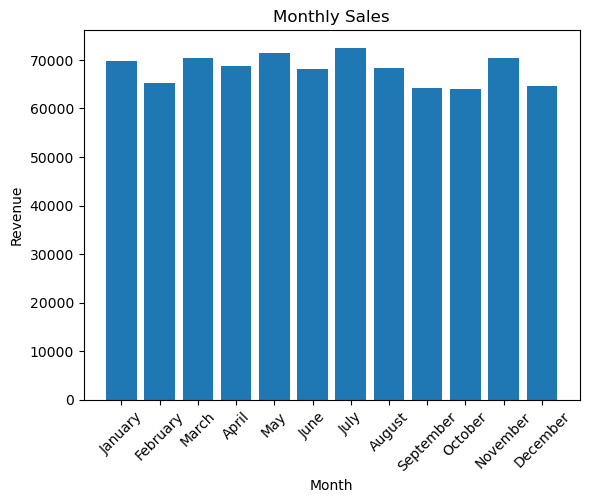

In [74]:
df["month_num"] = df["date"].dt.month
df["month"] = df["date"].dt.month_name()

monthly_sales = (
    df.groupby(["month_num", "month"])["revenue"]
    .sum()
    .reset_index()
    .sort_values("month_num")
)

plt.bar(monthly_sales["month"], monthly_sales["revenue"])

plt.title("Monthly Sales")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

### Insight

This shows how sales vary across different months.

## Question 10: Are there pizza types that are not doing well on the menu

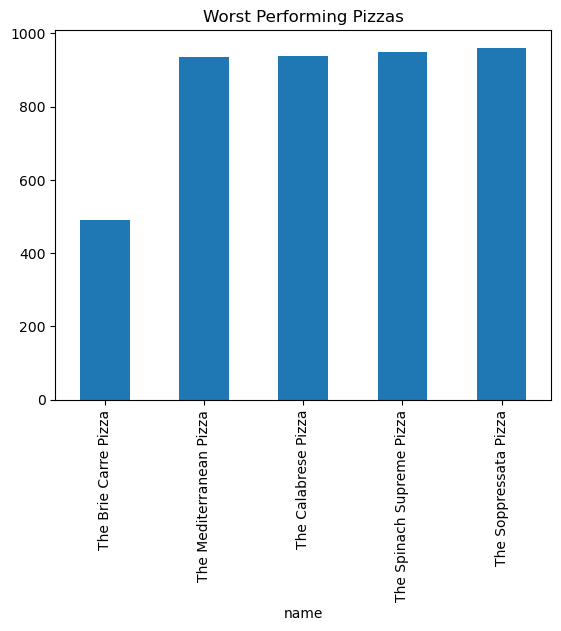

name
The Brie Carre Pizza         490
The Mediterranean Pizza      934
The Calabrese Pizza          937
The Spinach Supreme Pizza    950
The Soppressata Pizza        961
Name: quantity, dtype: int64

In [72]:
worst = df.groupby("name")["quantity"].sum().sort_values().head(5)

worst.plot(kind="bar")

plt.title("Worst Performing Pizzas")

plt.show()

worst

## Conclusion

This analysis revealed key insights about sales performance, customer behavior, and product popularity. The business can use these insights to improve sales strategies, optimize menu offerings, and maximize revenue.